# Khai phá toàn bộ dữ liệu — dữ liệu này có gì để phân tích?

Notebook này đọc đủ **14 CSV nguồn** và tạo một bản đồ phân tích trước khi xây model hay database.

Thứ tự làm việc:

1. Kiểm inventory, grain, khóa và từng cột.
2. Kiểm quan hệ để tránh join fan-out.
3. Tái tạo xương sống giao dịch và KPI tiền.
4. Khám phá các hướng phân tích: thời gian, sản phẩm, khách hàng, promotion, fulfillment, hậu mãi, tồn kho và traffic.
5. Chốt giới hạn dữ liệu và câu hỏi có thể trả lời.

Quy ước: **quan sát** là kết quả tính trực tiếp; **giả thuyết** là cách giải thích cần thêm bằng chứng. `sample_submission.csv` là output mẫu, không phải actual.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')

DATA = 'data'
R = lambda f, **k: pd.read_csv(f'{DATA}/{f}', low_memory=False, **k)

files = [
    'customers.csv', 'geography.csv', 'products.csv', 'promotions.csv',
    'orders.csv', 'order_items.csv', 'payments.csv', 'shipments.csv',
    'returns.csv', 'reviews.csv', 'inventory.csv', 'web_traffic.csv',
    'sales.csv', 'sample_submission.csv'
]
data = {f.removesuffix('.csv'): R(f) for f in files}

date_columns = {
    'customers': ['signup_date'], 'promotions': ['start_date', 'end_date'],
    'orders': ['order_date'], 'shipments': ['ship_date', 'delivery_date'],
    'returns': ['return_date'], 'reviews': ['review_date'],
    'inventory': ['snapshot_date'], 'web_traffic': ['date'],
    'sales': ['Date'], 'sample_submission': ['Date']
}
for table, columns in date_columns.items():
    for column in columns:
        data[table][column] = pd.to_datetime(data[table][column])

print(f'Đã đọc {len(data)}/14 nguồn, tổng {sum(len(df) for df in data.values()):,} dòng.')

Đã đọc 14/14 nguồn, tổng 2,960,736 dòng.


## 1. Inventory — có những bảng nào?

Bước đầu chỉ trả lời cấu trúc: kích thước, thời gian, grain, khóa và vai trò business. Không vội join hoặc tính KPI.

In [2]:
grain = {
    'customers': ('một khách hàng', 'customer_id', 'Khách hàng'),
    'geography': ('một mã zip', 'zip', 'Địa lý'),
    'products': ('một SKU/biến thể', 'product_id', 'Sản phẩm'),
    'promotions': ('một đợt promotion', 'promo_id', 'Promotion'),
    'orders': ('một đơn hàng', 'order_id', 'Giao dịch'),
    'order_items': ('một dòng hàng trong đơn', 'chưa có khóa nguồn hợp lệ', 'Giao dịch'),
    'payments': ('payment của một đơn', 'order_id', 'Thanh toán'),
    'shipments': ('shipment của một đơn', 'order_id', 'Fulfillment'),
    'returns': ('một event trả dòng hàng', 'return_id', 'Hậu mãi'),
    'reviews': ('một đánh giá dòng hàng', 'review_id', 'Hậu mãi'),
    'inventory': ('một sản phẩm tại snapshot cuối tháng', 'snapshot_date + product_id', 'Tồn kho'),
    'web_traffic': ('traffic tổng hợp của một ngày', 'date', 'Kênh số'),
    'sales': ('actual sales của một ngày', 'Date', 'Target lịch sử'),
    'sample_submission': ('một ngày tương lai cần dự báo', 'Date', 'Output mẫu')
}

def time_scope(name):
    columns = date_columns.get(name, [])
    if not columns:
        return 'Không có cột ngày'
    values = pd.concat([data[name][c].dropna() for c in columns], ignore_index=True)
    return f'{values.min().date()} → {values.max().date()}'

inventory_overview = pd.DataFrame([
    {'table': name, 'rows': len(df), 'columns': len(df.columns),
     'time_scope': time_scope(name), 'grain': grain[name][0],
     'source_key': grain[name][1], 'business_area': grain[name][2]}
    for name, df in data.items()
]).sort_values('business_area')
display(inventory_overview)

,table,rows,columns,time_scope,grain,source_key,business_area
7,shipments,566067,4,2012-07-04 → 2022-12-31,shipment của một đơn,order_id,Fulfillment
4,orders,646945,8,2012-07-04 → 2022-12-31,một đơn hàng,order_id,Giao dịch
5,order_items,714669,7,Không có cột ngày,một dòng hàng trong đơn,chưa có khóa nguồn hợp lệ,Giao dịch
8,returns,39939,7,2012-07-11 → 2022-12-31,một event trả dòng hàng,return_id,Hậu mãi
9,reviews,113551,7,2012-07-10 → 2022-12-31,một đánh giá dòng hàng,review_id,Hậu mãi
0,customers,121930,7,2012-01-17 → 2022-12-31,một khách hàng,customer_id,Khách hàng
11,web_traffic,3652,7,2013-01-01 → 2022-12-31,traffic tổng hợp của một ngày,date,Kênh số
13,sample_submission,548,3,2023-01-01 → 2024-07-01,một ngày tương lai cần dự báo,Date,Output mẫu
3,promotions,50,10,2013-01-31 → 2022-12-31,một đợt promotion,promo_id,Promotion
2,products,2412,8,Không có cột ngày,một SKU/biến thể,product_id,Sản phẩm


## 2. Profile toàn bộ cột và kiểm khóa

Profile giúp phát hiện cột rỗng, hằng số, cardinality thấp, domain bất thường và khóa không unique. `sample_values` chỉ hiển thị với cột có tối đa 10 giá trị.

In [3]:
profile_rows = []
for table, df in data.items():
    for column in df.columns:
        s = df[column]
        unique = s.nunique(dropna=True)
        samples = sorted(map(str, s.dropna().unique())) if unique <= 10 else []
        profile_rows.append({
            'table': table, 'column': column, 'dtype': str(s.dtype),
            'null_count': int(s.isna().sum()), 'null_pct': s.isna().mean() * 100,
            'unique': int(unique), 'sample_values': ', '.join(samples)
        })
column_profile = pd.DataFrame(profile_rows)
display(column_profile)

key_specs = {
    'customers': ['customer_id'], 'geography': ['zip'], 'products': ['product_id'],
    'promotions': ['promo_id'], 'orders': ['order_id'], 'payments': ['order_id'],
    'shipments': ['order_id'], 'returns': ['return_id'], 'reviews': ['review_id'],
    'inventory': ['snapshot_date', 'product_id'], 'web_traffic': ['date'],
    'sales': ['Date'], 'sample_submission': ['Date']
}
key_report = []
for table, key in key_specs.items():
    df = data[table]
    key_report.append({'table': table, 'candidate_key': ' + '.join(key),
                       'null_key_rows': int(df[key].isna().any(axis=1).sum()),
                       'duplicate_key_rows': int(df.duplicated(key).sum()),
                       'key_valid': not df[key].isna().any(axis=1).any() and not df.duplicated(key).any()})
display(pd.DataFrame(key_report))

items = data['order_items'].copy()
duplicate_item_pairs = items[items.duplicated(['order_id', 'product_id'], keep=False)]
items['line_number'] = items.groupby('order_id', sort=False).cumcount() + 1
print(f'order_items: {len(duplicate_item_pairs):,} dòng thuộc {duplicate_item_pairs.groupby(["order_id", "product_id"]).ngroups} cặp (order_id, product_id) trùng.')
print(f'Khóa sinh (order_id, line_number) trùng: {items.duplicated(["order_id", "line_number"]).sum()}')
display(duplicate_item_pairs.sort_values(['order_id', 'product_id']).head(8))

,table,column,dtype,null_count,null_pct,unique,sample_values
0,customers,customer_id,int64,0,0.000,121930,
1,customers,zip,int64,0,0.000,31491,
2,customers,city,str,0,0.000,42,
3,customers,signup_date,datetime64[us],0,0.000,3941,
4,customers,gender,str,0,0.000,3,"Female, Male, Non-binary"
5,customers,age_group,str,0,0.000,5,"18-24, 25-34, 35-44, 45-54, 55+"
6,customers,acquisition_channel,str,0,0.000,6,"direct, email_campaign, organic_search, paid_s..."
7,geography,zip,int64,0,0.000,39948,
8,geography,city,str,0,0.000,42,
9,geography,region,str,0,0.000,3,"Central, East, West"


,table,candidate_key,null_key_rows,duplicate_key_rows,key_valid
0,customers,customer_id,0,0,True
1,geography,zip,0,0,True
2,products,product_id,0,0,True
3,promotions,promo_id,0,0,True
4,orders,order_id,0,0,True
5,payments,order_id,0,0,True
6,shipments,order_id,0,0,True
7,returns,return_id,0,0,True
8,reviews,review_id,0,0,True
9,inventory,snapshot_date + product_id,0,0,True


order_items: 32 dòng thuộc 16 cặp (order_id, product_id) trùng.
Khóa sinh (order_id, line_number) trùng: 0


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
12233,14280,976,1,"4,019.470",0.000,NaN,NaN
12234,14280,976,2,"3,937.990",0.000,NaN,NaN
99645,113379,786,6,694.340,0.000,NaN,NaN
99646,113379,786,1,699.370,0.000,NaN,NaN
189239,215525,1859,5,"1,896.110",0.000,NaN,NaN
189240,215525,1859,5,"1,897.200",0.000,NaN,NaN
190291,216740,791,8,793.100,0.000,NaN,NaN
190292,216740,791,5,825.520,0.000,NaN,NaN


## 3. Quan hệ — có join được an toàn không?

Kiểm orphan trên 15 liên kết cột nguồn. Hai cột promo được tính riêng; sau chuẩn hóa chúng trở thành một quan hệ M:N.

In [4]:
relationships = [
    ('customers', 'zip', 'geography', 'zip'),
    ('orders', 'customer_id', 'customers', 'customer_id'), ('orders', 'zip', 'geography', 'zip'),
    ('order_items', 'order_id', 'orders', 'order_id'), ('order_items', 'product_id', 'products', 'product_id'),
    ('order_items', 'promo_id', 'promotions', 'promo_id'), ('order_items', 'promo_id_2', 'promotions', 'promo_id'),
    ('payments', 'order_id', 'orders', 'order_id'), ('shipments', 'order_id', 'orders', 'order_id'),
    ('returns', 'order_id', 'orders', 'order_id'), ('returns', 'product_id', 'products', 'product_id'),
    ('reviews', 'order_id', 'orders', 'order_id'), ('reviews', 'product_id', 'products', 'product_id'),
    ('reviews', 'customer_id', 'customers', 'customer_id'),
    ('inventory', 'product_id', 'products', 'product_id')
]
relationship_report = []
for child, child_key, parent, parent_key in relationships:
    values = data[child][child_key].dropna()
    relationship_report.append({
        'relationship': f'{child}.{child_key} → {parent}.{parent_key}',
        'non_null_child_rows': len(values),
        'orphan_rows': int((~values.isin(data[parent][parent_key])).sum())
    })
relationship_report = pd.DataFrame(relationship_report)
display(relationship_report)
print(f'Tổng orphan: {relationship_report.orphan_rows.sum():,}')

,relationship,non_null_child_rows,orphan_rows
0,customers.zip → geography.zip,121930,0
1,orders.customer_id → customers.customer_id,646945,0
2,orders.zip → geography.zip,646945,0
3,order_items.order_id → orders.order_id,714669,0
4,order_items.product_id → products.product_id,714669,0
5,order_items.promo_id → promotions.promo_id,276316,0
6,order_items.promo_id_2 → promotions.promo_id,206,0
7,payments.order_id → orders.order_id,646945,0
8,shipments.order_id → orders.order_id,566067,0
9,returns.order_id → orders.order_id,39939,0


Tổng orphan: 0


## 4. Xương sống giao dịch và KPI tiền

Tái tạo một bảng phân tích ở grain dòng hàng để phân biệt Gross Revenue, Net Sales và COGS.

In [5]:
orders = data['orders']; products = data['products']; payments = data['payments']
item_fact = (items
    .merge(orders[['order_id', 'order_date', 'customer_id']], on='order_id', validate='many_to_one')
    .merge(products[['product_id', 'product_name', 'category', 'segment', 'cogs']],
           on='product_id', validate='many_to_one'))
item_fact['gross_revenue'] = item_fact.quantity * item_fact.unit_price
item_fact['net_sales'] = item_fact.gross_revenue - item_fact.discount_amount
item_fact['line_cogs'] = item_fact.quantity * item_fact.cogs
item_fact['gross_profit'] = item_fact.net_sales - item_fact.line_cogs

overall = pd.DataFrame({'value': {
    'orders': orders.order_id.nunique(), 'customers_with_orders': orders.customer_id.nunique(),
    'order_lines': len(item_fact), 'units': item_fact.quantity.sum(),
    'gross_revenue': item_fact.gross_revenue.sum(), 'discount': item_fact.discount_amount.sum(),
    'net_sales': item_fact.net_sales.sum(), 'cogs': item_fact.line_cogs.sum(),
    'gross_profit_after_discount': item_fact.gross_profit.sum(),
    'gross_margin_pct': item_fact.gross_profit.sum() / item_fact.net_sales.sum() * 100,
    'aov_net': item_fact.net_sales.sum() / orders.order_id.nunique()
}})
display(overall)

daily = item_fact.groupby('order_date', as_index=False).agg(
    Revenue=('gross_revenue', 'sum'), COGS=('line_cogs', 'sum'))
sales_compare = data['sales'].merge(daily, left_on='Date', right_on='order_date', suffixes=('_source', '_derived'))
order_net = item_fact.groupby('order_id').net_sales.sum()
payment_compare = payments.set_index('order_id').join(order_net.rename('net_derived'))
print('Sai số tuyệt đối lớn nhất:')
print('  sales.Revenue:', (sales_compare.Revenue_source - sales_compare.Revenue_derived).abs().max())
print('  sales.COGS   :', (sales_compare.COGS_source - sales_compare.COGS_derived).abs().max())
print('  payment_value:', (payment_compare.payment_value - payment_compare.net_derived).abs().max())

,value
orders,"646,945.000"
customers_with_orders,"90,246.000"
order_lines,"714,669.000"
units,"3,213,143.000"
gross_revenue,"16,430,476,585.530"
discount,"749,607,320.100"
net_sales,"15,680,869,265.430"
cogs,"14,163,450,519.128"
gross_profit_after_discount,"1,517,418,746.302"
gross_margin_pct,9.677


Sai số tuyệt đối lớn nhất:
  sales.Revenue: 1.862645149230957e-09
  sales.COGS   : 0.00499926891643554
  payment_value: 5.820766091346741e-11


## 5. Phân tích theo thời gian

Có thể nghiên cứu trend, structural break, seasonality tháng, ngày-trong-tháng và tỷ lệ COGS/Revenue. Không dùng một xu hướng duy nhất xuyên qua cuối 2018.

,Revenue,COGS
year,,
2012,741.498,587.462
2013,"1,657.169","1,465.980"
2014,"1,871.846","1,574.607"
2015,"1,889.934","1,665.442"
2016,"2,104.641","1,780.559"
2017,"1,911.164","1,694.386"
2018,"1,850.122","1,542.176"
2019,"1,136.801","1,005.203"
2020,"1,054.512",886.085


,revenue_index
month,
1,0.602
2,0.818
3,1.172
4,1.522
5,1.525
6,1.483
7,1.085
8,1.037
9,0.892


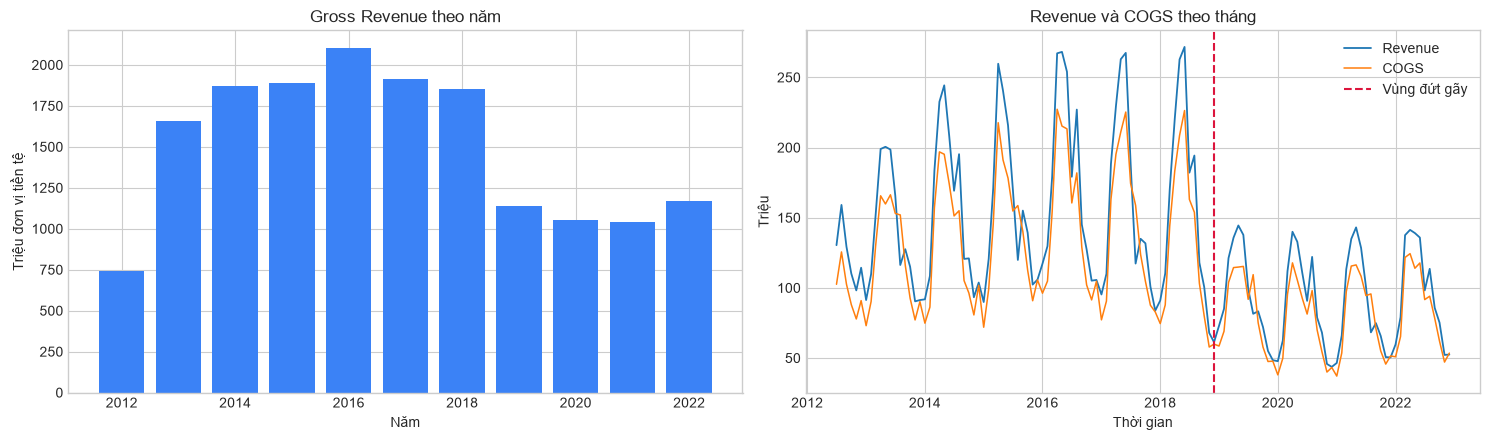

In [6]:
daily_time = daily.copy()
daily_time['year'] = daily_time.order_date.dt.year
daily_time['month'] = daily_time.order_date.dt.month
daily_time['day'] = daily_time.order_date.dt.day
daily_time['cogs_revenue_ratio'] = daily_time.COGS / daily_time.Revenue
annual = daily_time.groupby('year')[['Revenue', 'COGS']].sum() / 1e6
monthly = daily_time.set_index('order_date')[['Revenue', 'COGS']].resample('MS').sum() / 1e6
seasonality = (daily_time.assign(rev_norm=daily_time.Revenue / daily_time.groupby('year').Revenue.transform('mean'))
               .groupby('month').rev_norm.mean().rename('revenue_index').to_frame())
display(annual, seasonality)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(annual.index, annual.Revenue, color='#3B82F6')
axes[0].set(title='Gross Revenue theo năm', xlabel='Năm', ylabel='Triệu đơn vị tiền tệ')
axes[1].plot(monthly.index, monthly.Revenue, label='Revenue', lw=1.3)
axes[1].plot(monthly.index, monthly.COGS, label='COGS', lw=1.1)
axes[1].axvline(pd.Timestamp('2018-12-01'), color='crimson', ls='--', label='Vùng đứt gãy')
axes[1].set(title='Revenue và COGS theo tháng', xlabel='Thời gian', ylabel='Triệu')
axes[1].legend()
plt.tight_layout(); plt.show()

## 6. Sản phẩm, khách hàng và thị trường

Các hướng chính: quy mô và margin theo category/segment; region nào tạo doanh thu; acquisition channel nào đi cùng nhiều khách/đơn. `acquisition_channel` không phải attribution chắc chắn cho từng order.

In [7]:
customers = data['customers']; geography = data['geography']
customer_dim = customers[['customer_id', 'zip', 'acquisition_channel']].merge(
    geography[['zip', 'region']], on='zip', validate='many_to_one')
business_fact = item_fact.merge(customer_dim, on='customer_id', validate='many_to_one')

def summarize(column):
    out = business_fact.groupby(column, as_index=False).agg(
        orders=('order_id', 'nunique'), customers=('customer_id', 'nunique'), units=('quantity', 'sum'),
        gross_revenue=('gross_revenue', 'sum'), net_sales=('net_sales', 'sum'),
        cogs=('line_cogs', 'sum'), gross_profit=('gross_profit', 'sum'))
    out['gross_margin_pct'] = out.gross_profit / out.net_sales * 100
    return out.sort_values('net_sales', ascending=False)

for dimension in ['category', 'segment', 'region', 'acquisition_channel']:
    print(f'KPI theo {dimension}')
    display(summarize(dimension))

KPI theo category


,category,orders,customers,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
3,Streetwear,389543,77215,1768826,"13,131,346,352.620","12,558,477,099.170","11,392,669,587.624","1,165,807,511.546",9.283
2,Outdoor,200454,59121,1170000,"2,494,882,754.200","2,353,396,796.860","2,086,362,704.837","267,034,092.023",11.347
0,Casual,23600,17136,107469,"460,648,383.350","440,285,193.750","406,544,428.515","33,740,765.235",7.663
1,GenZ,37054,23350,166848,"343,599,095.360","328,710,175.650","277,873,798.151","50,836,377.499",15.465


KPI theo segment


,segment,orders,customers,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
3,Everyday,181514,60757,819449,"5,376,848,662.270","5,147,454,916.610","4,615,280,157.291","532,174,759.319",10.339
2,Balanced,103023,46273,464217,"5,127,408,523.480","4,900,317,965.890","4,469,081,905.229","431,236,060.661",8.800
4,Performance,96303,40622,435685,"2,390,412,021.170","2,285,029,332.180","2,111,335,495.523","173,693,836.657",7.601
0,Activewear,171011,55320,1036857,"2,047,815,224.180","1,930,704,974.660","1,684,365,425.473","246,339,549.187",12.759
5,Premium,30944,20049,139465,"480,131,388.390","454,211,900.540","427,625,674.404","26,586,226.136",5.853
1,All-weather,22553,16674,101147,"427,584,524.980","408,765,115.410","380,916,033.476","27,849,081.934",6.813
7,Trendy,37054,23350,166848,"343,599,095.360","328,710,175.650","277,873,798.151","50,836,377.499",15.465
6,Standard,10924,9141,49475,"236,677,145.700","225,674,884.490","196,972,029.580","28,702,854.910",12.719


KPI theo region


,region,orders,customers,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
1,East,294612,44721,1443711,"7,637,532,676.200","7,291,150,819.120","6,595,502,515.507","695,648,303.613",9.541
0,Central,184691,30784,906968,"4,941,908,471.680","4,719,491,267.840","4,276,430,336.768","443,060,931.072",9.388
2,West,167642,14741,862464,"3,851,035,437.650","3,670,227,178.470","3,291,517,666.853","378,709,511.617",10.318


KPI theo acquisition_channel


,acquisition_channel,orders,customers,units,gross_revenue,net_sales,cogs,gross_profit,gross_margin_pct
2,organic_search,194227,26950,965538,"4,937,571,851.570","4,712,188,230.960","4,260,908,083.458","451,280,147.502",9.577
5,social_media,129498,18002,642937,"3,308,171,218.510","3,158,597,505.410","2,847,655,526.277","310,941,979.133",9.844
3,paid_search,128953,17999,639564,"3,271,722,558.110","3,122,379,325.110","2,816,526,094.955","305,853,230.155",9.796
1,email_campaign,77775,10886,386032,"1,967,111,032.670","1,876,906,366.800","1,694,732,955.142","182,173,411.658",9.706
4,referral,64473,9072,321439,"1,634,969,451.480","1,559,981,529.930","1,412,435,463.869","147,546,066.061",9.458
0,direct,52019,7337,257633,"1,310,930,473.190","1,250,816,307.220","1,131,192,395.427","119,623,911.793",9.564


## 7. Promotion

Hai cột `promo_id`/`promo_id_2` là repeating group. Phân tích promotion phải unpivot về grain `(order_id, line_number, promo_id)`. Một dòng có hai promo sẽ xuất hiện hai lần, nên không cộng doanh thu qua promotion để suy ra tổng toàn hệ thống.

In [8]:
promotions = data['promotions']
promo_long = (items[['order_id', 'line_number', 'promo_id', 'promo_id_2']]
              .melt(id_vars=['order_id', 'line_number'], value_name='promo_code')
              .dropna(subset=['promo_code']).drop(columns='variable')
              .rename(columns={'promo_code': 'promo_id'}))
promo_analysis = (promo_long
    .merge(promotions[['promo_id', 'promo_name', 'promo_type', 'applicable_category']], on='promo_id')
    .merge(item_fact[['order_id', 'line_number', 'gross_revenue', 'net_sales', 'gross_profit']],
           on=['order_id', 'line_number'], validate='many_to_one'))
promo_summary = (promo_analysis.groupby(['promo_id', 'promo_name'], as_index=False)
                 .agg(item_links=('line_number', 'count'), gross_revenue=('gross_revenue', 'sum'),
                      net_sales=('net_sales', 'sum'), gross_profit=('gross_profit', 'sum'))
                 .sort_values('net_sales', ascending=False))
print(f'Dòng có promo_id: {items.promo_id.notna().sum():,}')
print(f'Dòng có promo_id_2: {items.promo_id_2.notna().sum():,}')
print(f'Tổng liên kết sau unpivot: {len(promo_long):,}')
display(promo_summary.head(10))

Dòng có promo_id: 276,316
Dòng có promo_id_2: 206
Tổng liên kết sau unpivot: 276,522


,promo_id,promo_name,item_links,gross_revenue,net_sales,gross_profit
20,PROMO-0021,Spring Sale 2017,8966,"204,302,311.940","179,786,034.740","-6,451,210.176"
10,PROMO-0011,Spring Sale 2015,9594,"200,252,222.110","176,221,955.010","-3,686,684.605"
16,PROMO-0017,Spring Sale 2016,8808,"194,960,201.490","171,564,977.240","-6,513,585.194"
6,PROMO-0007,Spring Sale 2014,9373,"184,829,965.790","162,650,369.750","-6,504,706.282"
26,PROMO-0027,Spring Sale 2018,7518,"169,268,894.510","148,956,627.410","-3,426,928.357"
0,PROMO-0001,Spring Sale 2013,8523,"162,063,135.660","142,615,559.510","-2,985,823.433"
27,PROMO-0028,Mid-Year Sale 2018,8146,"171,702,303.720","140,795,889.580","-25,028,846.885"
12,PROMO-0013,Fall Launch 2015,7498,"152,803,790.190","137,516,810.070","1,385,017.871"
21,PROMO-0022,Mid-Year Sale 2017,7506,"164,403,985.890","134,811,268.620","-25,700,027.406"
18,PROMO-0019,Fall Launch 2016,5763,"135,629,520.370","122,066,567.290","403,896.238"


## 8. Thanh toán và fulfillment

Có thể phân tích payment mix, installments, delivery lead time, shipping fee và đơn chưa có shipment. `shipping_fee` không nằm trong Revenue và có thể khác đơn vị với giá trị hàng.

In [9]:
payment_summary = (payments.groupby('payment_method', as_index=False)
                   .agg(orders=('order_id', 'count'), net_payment=('payment_value', 'sum'),
                        avg_installments=('installments', 'mean'))
                   .sort_values('net_payment', ascending=False))
shipments = data['shipments'].copy()
shipments['delivery_days'] = (shipments.delivery_date - shipments.ship_date).dt.days
missing_shipments = (orders[~orders.order_id.isin(shipments.order_id)]
                     .order_status.value_counts().rename_axis('order_status').rename('missing_shipments').to_frame())
shipment_kpi = pd.DataFrame({'value': {
    'shipments': len(shipments), 'avg_delivery_days': shipments.delivery_days.mean(),
    'median_delivery_days': shipments.delivery_days.median(),
    'avg_shipping_fee': shipments.shipping_fee.mean(),
    'free_shipping_rate': shipments.shipping_fee.eq(0).mean(),
    'orders_without_shipment': len(orders) - shipments.order_id.nunique()
}})
display(payment_summary, shipment_kpi, missing_shipments)

,payment_method,orders,net_payment,avg_installments
3,credit_card,356352,"8,630,069,413.190",3.880
4,paypal,97018,"2,363,680,137.730",3.878
2,cod,96681,"2,346,947,592.930",1.000
0,apple_pay,64763,"1,564,269,610.500",3.881
1,bank_transfer,32131,"775,902,511.080",3.853


,value
shipments,"566,067.000"
avg_delivery_days,4.499
median_delivery_days,4.000
avg_shipping_fee,4.963
free_shipping_rate,0.001
orders_without_shipment,"80,878.000"


,missing_shipments
order_status,
cancelled,59462
paid,13577
created,7275
delivered,524
returned,29
shipped,11


## 9. Return và review

Return/review là hậu mãi ở grain dòng hàng. Nguồn thiếu `line_number`, nên mapping dưới đây dùng occurrence theo thứ tự nguồn. Đây là quy tắc tái lập được nhưng không phải ground truth được cung cấp.

In [10]:
item_key = items[['order_id', 'product_id', 'line_number', 'quantity']].copy()
item_key['occurrence_number'] = item_key.groupby(['order_id', 'product_id'], sort=False).cumcount() + 1
duplicate_pairs = item_key.groupby(['order_id', 'product_id']).size().loc[lambda s: s.gt(1)].reset_index()

def map_child_to_line(child):
    mapped = child.copy()
    mapped['occurrence_number'] = mapped.groupby(['order_id', 'product_id'], sort=False).cumcount() + 1
    return mapped.merge(item_key, on=['order_id', 'product_id', 'occurrence_number'],
                        how='left', validate='one_to_one')

return_map = map_child_to_line(data['returns'])
review_map = map_child_to_line(data['reviews'])
return_fact = return_map.merge(item_fact[['order_id', 'line_number', 'category']],
                               on=['order_id', 'line_number'], validate='one_to_one')
review_fact = review_map.merge(item_fact[['order_id', 'line_number', 'category']],
                               on=['order_id', 'line_number'], validate='one_to_one')
post_purchase = pd.DataFrame({'value': {
    'return_line_rate': len(return_fact) / len(item_fact),
    'return_unit_rate': return_fact.return_quantity.sum() / item_fact.quantity.sum(),
    'refund_over_net_sales': return_fact.refund_amount.sum() / item_fact.net_sales.sum(),
    'average_rating': review_fact.rating.mean(),
    'ambiguous_return_rows': len(data['returns'].merge(duplicate_pairs[['order_id', 'product_id']],
                                                        on=['order_id', 'product_id'], how='inner')),
    'ambiguous_review_rows': len(data['reviews'].merge(duplicate_pairs[['order_id', 'product_id']],
                                                        on=['order_id', 'product_id'], how='inner')),
    'return_quantity_over_item_quantity': int(return_fact.return_quantity.gt(return_fact.quantity).sum())
}})
return_by_category = return_fact.groupby('category').agg(return_lines=('return_id', 'count'), returned_units=('return_quantity', 'sum'))
review_by_category = review_fact.groupby('category').agg(reviews=('review_id', 'count'), avg_rating=('rating', 'mean'))
display(post_purchase, return_by_category.join(review_by_category))

,value
return_line_rate,0.056
return_unit_rate,0.034
refund_over_net_sales,0.033
average_rating,3.936
ambiguous_return_rows,4.000
ambiguous_review_rows,2.000
return_quantity_over_item_quantity,0.000


,return_lines,returned_units,reviews,avg_rating
category,,,,
Casual,1294,3499,3790,3.923
GenZ,2126,5869,5792,3.923
Outdoor,14720,40417,41265,3.934
Streetwear,21799,59801,62704,3.939


## 10. Inventory

Inventory dùng cho stockout, overstock, days of supply và sell-through tại snapshot. Không dùng `units_sold` của bảng này thay cho giao dịch vì hai nguồn không reconcile.

In [11]:
inventory = data['inventory'].copy()
dos = (inventory.stock_on_hand / (inventory.units_sold / 30)).round(1)
formula_check = pd.DataFrame({
    'column': ['stockout_flag', 'days_of_supply', 'fill_rate', 'sell_through_rate', 'overstock_flag'],
    'match_pct': [
        inventory.stockout_flag.eq(inventory.stockout_days.gt(0).astype(int)).mean() * 100,
        np.isclose(inventory.days_of_supply, dos, atol=1e-9).mean() * 100,
        np.isclose(inventory.fill_rate, (1-inventory.stockout_days/30).round(4), atol=1e-9).mean() * 100,
        np.isclose(inventory.sell_through_rate,
                   (inventory.units_sold/(inventory.stock_on_hand+inventory.units_sold)).round(4), atol=1e-9).mean() * 100,
        inventory.overstock_flag.eq(dos.gt(90).astype(int)).mean() * 100
    ]
})
latest = inventory[inventory.snapshot_date.eq(inventory.snapshot_date.max())]
latest_summary = latest.groupby('category', as_index=False).agg(
    products=('product_id', 'nunique'), stock_on_hand=('stock_on_hand', 'sum'),
    units_sold=('units_sold', 'sum'), stockout_rate=('stockout_flag', 'mean'),
    overstock_rate=('overstock_flag', 'mean'), avg_days_of_supply=('days_of_supply', 'mean'))
print(f'Snapshot mới nhất: {inventory.snapshot_date.max().date()}')
display(formula_check, latest_summary)

Snapshot mới nhất: 2022-12-31


,column,match_pct
0,stockout_flag,100.000
1,days_of_supply,100.000
2,fill_rate,100.000
3,sell_through_rate,100.000
4,overstock_flag,100.000


,category,products,stock_on_hand,units_sold,stockout_rate,overstock_rate,avg_days_of_supply
0,Casual,40,4095,190,0.775,0.725,830.952
1,GenZ,44,5126,199,0.568,0.841,"1,019.416"
2,Outdoor,144,49929,1797,0.660,0.785,"2,196.005"
3,Streetwear,196,45085,1379,0.684,0.827,"2,031.817"


## 11. Web traffic

Có thể phân tích đồng biến theo ngày giữa traffic và sales. Không có `session_id`, `customer_id` hoặc `order_id`, nên correlation không phải conversion hay causality.

In [12]:
traffic = data['web_traffic']
daily_orders = orders.groupby('order_date', as_index=False).agg(orders=('order_id', 'nunique'))
traffic_sales = (traffic.merge(daily, left_on='date', right_on='order_date', validate='one_to_one')
                 .merge(daily_orders, on='order_date', validate='one_to_one'))
traffic_sales['orders_per_session_proxy'] = traffic_sales.orders / traffic_sales.sessions
traffic_summary = pd.DataFrame({'value': {
    'matched_days': len(traffic_sales),
    'corr_sessions_revenue': traffic_sales.sessions.corr(traffic_sales.Revenue),
    'corr_visitors_revenue': traffic_sales.unique_visitors.corr(traffic_sales.Revenue),
    'avg_orders_per_session_proxy': traffic_sales.orders_per_session_proxy.mean(),
    'avg_bounce_rate': traffic.bounce_rate.mean()
}})
display(traffic_summary)

,value
matched_days,"3,652.000"
corr_sessions_revenue,0.321
corr_visitors_revenue,0.319
avg_orders_per_session_proxy,0.007
avg_bounce_rate,0.004


## 12. Bản đồ câu hỏi có thể phân tích

| Miền | Câu hỏi | Bảng chính | KPI/feature | Giới hạn |
|---|---|---|---|---|
| Thời gian | Trend, seasonality, structural break? | sales, order, order_items | Revenue, COGS, ratio, order count | Không fit một trend qua 2018 |
| Sản phẩm | Category/segment nào tạo value và margin? | order_items, products | units, net sales, gross margin | Giá product là snapshot |
| Khách hàng | Region/channel nào tạo nhiều đơn? | customers, geography, orders | customers, orders, AOV | Signup date không đáng tin |
| Promotion | Promo nào đi cùng thay đổi volume/margin? | promotions, order_items | promoted lines, discount, profit | Association, chưa chứng minh uplift causal |
| Thanh toán | Payment mix và installments? | payments, orders | net payment, orders | Payment là net, sales là gross |
| Fulfillment | Lead time, phí ship, thiếu shipment? | shipments, orders | delivery days, shipping fee | Không có carrier/SLA |
| Hậu mãi | Category nào có return/rating đáng chú ý? | returns, reviews, order_items | return rate, refund, rating | Line mapping là giả định tái dựng |
| Inventory | SKU/category nào stockout hoặc overstock? | inventory, products | DOS, fill rate, sell-through | units_sold độc lập giao dịch |
| Digital | Traffic cùng biến động với sales? | web_traffic, sales | sessions, visitors, correlation | Không có session/order FK |
| Forecasting | Feature nào có ở tương lai? | sales, calendar, promotions | month, day, parity, regime | Bảng phụ dừng ở 2022-12-31 |

In [13]:
quality_issues = pd.DataFrame([
    ('order_items', '16 cặp (order_id, product_id) trùng', 'Sinh line_number; không group làm mất dòng'),
    ('returns/reviews', '4 return và 2 review nằm trên cặp item nhập nhằng', 'Công bố giả định occurrence mapping'),
    ('customers', '73,8% đơn trước signup_date', 'Không dùng tenure/cohort'),
    ('products', '654 SKU price < 100 chưa từng bán', 'Cờ audit, không tạo dimension price_tier'),
    ('orders/returns', 'Order status returned và bảng returns không cùng source of truth', 'Định nghĩa KPI rõ grain'),
    ('shipments', '80.878 order không có shipment', 'Đọc cùng lifecycle status'),
    ('inventory', '5 cột dẫn xuất; reorder_flag hằng số', 'Tính khi đọc, bỏ dư thừa'),
    ('inventory', 'units_sold không reconcile giao dịch', 'Coi là nguồn vận hành độc lập'),
    ('web_traffic', 'Một dòng/ngày nhưng mang một traffic_source', 'Không coi là breakdown theo source'),
    ('sales/payments', 'Revenue gross khác payment net', 'Không trộn metric')
], columns=['table', 'observation', 'analysis_rule'])
display(quality_issues)

,table,observation,analysis_rule
0,order_items,"16 cặp (order_id, product_id) trùng",Sinh line_number; không group làm mất dòng
1,returns/reviews,4 return và 2 review nằm trên cặp item nhập nhằng,Công bố giả định occurrence mapping
2,customers,"73,8% đơn trước signup_date",Không dùng tenure/cohort
3,products,654 SKU price < 100 chưa từng bán,"Cờ audit, không tạo dimension price_tier"
4,orders/returns,Order status returned và bảng returns không cù...,Định nghĩa KPI rõ grain
5,shipments,80.878 order không có shipment,Đọc cùng lifecycle status
6,inventory,5 cột dẫn xuất; reorder_flag hằng số,"Tính khi đọc, bỏ dư thừa"
7,inventory,units_sold không reconcile giao dịch,Coi là nguồn vận hành độc lập
8,web_traffic,Một dòng/ngày nhưng mang một traffic_source,Không coi là breakdown theo source
9,sales/payments,Revenue gross khác payment net,Không trộn metric


## 13. Bằng chứng bất thường và nguyên nhân

Phần này **show trực tiếp kết quả** cho từng nhận định. Cột `cause_status` phân biệt:

- **Đã chứng minh:** phép tính hoặc cách join chỉ ra cơ chế trực tiếp.
- **Giải thích được một phần:** dữ liệu cho thấy driver gần nhất nhưng thiếu nguyên nhân gốc.
- **Giả thuyết:** pattern đáng nghi nhưng nguồn không có metadata để kết luận.

### 13.1 Giá sản phẩm và `signup_date`

In [14]:
sold_products = set(items.product_id.unique())
item_price = items.merge(products[['product_id', 'price']], on='product_id', validate='many_to_one')
item_price['line_value'] = item_price.quantity * item_price.unit_price
price_slices = []
for label, mask in [
    ('price < 100', products.price.lt(100)),
    ('100 <= price < 1.000', products.price.ge(100) & products.price.lt(1000)),
    ('price >= 1.000', products.price.ge(1000))
]:
    sku_ids = set(products.loc[mask, 'product_id'])
    sold_mask = item_price.product_id.isin(sku_ids)
    price_slices.append({
        'price_slice': label, 'skus': int(mask.sum()),
        'skus_ever_sold': int(products.loc[mask, 'product_id'].isin(sold_products).sum()),
        'order_line_pct': sold_mask.mean() * 100,
        'revenue_pct': item_price.loc[sold_mask, 'line_value'].sum() / item_price.line_value.sum() * 100
    })
price_evidence = pd.DataFrame(price_slices)
duplicate_variants = products[products.duplicated(['product_name', 'size', 'color'], keep=False)].sort_values(
    ['product_name', 'size', 'color', 'price'])

signup_join = orders.merge(customers[['customer_id', 'signup_date']], on='customer_id', validate='many_to_one')
before_signup = signup_join.order_date.lt(signup_join.signup_date)
signup_evidence = pd.DataFrame({'value': {
    'orders': len(signup_join),
    'orders_before_signup': int(before_signup.sum()),
    'orders_before_signup_pct': before_signup.mean() * 100,
    'median_days_order_before_signup': (signup_join.signup_date-signup_join.order_date)[before_signup].dt.days.median()
}})
print('Phân lớp giá — nhóm <100 không tạo một dòng bán nào; nhóm 100–1.000 vẫn là hàng bán hợp lệ:')
display(price_evidence)
print(f'Số bản ghi sau bản ghi đầu tiên bị trùng (product_name, size, color): {products.duplicated(["product_name", "size", "color"]).sum():,}')
display(duplicate_variants[['product_id', 'product_name', 'size', 'color', 'price', 'cogs']].head(8))
print('Kiểm tra thứ tự order_date và signup_date:')
display(signup_evidence)

Phân lớp giá — nhóm <100 không tạo một dòng bán nào; nhóm 100–1.000 vẫn là hàng bán hợp lệ:


,price_slice,skus,skus_ever_sold,order_line_pct,revenue_pct
0,price < 100,654,0,0.000,0.000
1,100 <= price < 1.000,34,30,7.456,1.064
2,price >= 1.000,1724,1568,92.544,98.936


Số bản ghi sau bản ghi đầu tiên bị trùng (product_name, size, color): 240


,product_id,product_name,size,color,price,cogs
745,380,LotusWear UE-01,S,red,34.036,21.344
645,280,LotusWear UE-01,S,red,"12,596.850","11,967.007"
746,381,LotusWear UE-02,M,black,21.652,12.139
646,281,LotusWear UE-02,M,black,"15,746.850","8,750.525"
747,382,LotusWear UE-03,L,orange,"11,147.850","10,315.106"
647,282,LotusWear UE-03,L,orange,"14,486.850","12,008.150"
648,283,LotusWear UE-04,XL,blue,24.025,15.411
748,383,LotusWear UE-04,XL,blue,"7,286.850","6,664.553"


Kiểm tra thứ tự order_date và signup_date:


,value
orders,"646,945.000"
orders_before_signup,"477,453.000"
orders_before_signup_pct,73.801
median_days_order_before_signup,"1,468.000"


### 13.2 Shipment, return status và đơn vị tiền

In [15]:
missing_shipment_evidence = (orders[~orders.order_id.isin(shipments.order_id)]
    .order_status.value_counts().sort_index().rename_axis('order_status').rename('orders_without_shipment').to_frame())
missing_shipment_evidence['assessment'] = np.where(
    missing_shipment_evidence.index.isin(['created', 'paid', 'cancelled']),
    'Có thể hợp lý theo lifecycle', 'Đáng nghi: status hàm ý đã fulfillment')

status_returned = set(orders.loc[orders.order_status.eq('returned'), 'order_id'])
return_events = set(data['returns'].order_id)
return_truth_evidence = pd.DataFrame({'orders': {
    'status_returned': len(status_returned),
    'has_return_event': len(return_events),
    'status_only': len(status_returned-return_events),
    'event_only': len(return_events-status_returned),
    'intersection': len(status_returned & return_events)
}})
money_scale_evidence = pd.DataFrame({'min': [shipments.shipping_fee.min(), payments.payment_value.min()],
                                     'median': [shipments.shipping_fee.median(), payments.payment_value.median()],
                                     'max': [shipments.shipping_fee.max(), payments.payment_value.max()]},
                                    index=['shipping_fee', 'payment_value'])
print('Đơn thiếu shipment theo lifecycle:')
display(missing_shipment_evidence)
print('Order status returned và return event không hoàn toàn cùng một tập:')
display(return_truth_evidence)
print('Hai thang số tiền không nên cộng trực tiếp khi chưa xác minh đơn vị:')
display(money_scale_evidence)

Đơn thiếu shipment theo lifecycle:


,orders_without_shipment,assessment
order_status,,
cancelled,59462,Có thể hợp lý theo lifecycle
created,7275,Có thể hợp lý theo lifecycle
delivered,524,Đáng nghi: status hàm ý đã fulfillment
paid,13577,Có thể hợp lý theo lifecycle
returned,29,Đáng nghi: status hàm ý đã fulfillment
shipped,11,Đáng nghi: status hàm ý đã fulfillment


Order status returned và return event không hoàn toàn cùng một tập:


,orders
status_returned,36142
has_return_event,36062
status_only,80
event_only,0
intersection,36062


Hai thang số tiền không nên cộng trực tiếp khi chưa xác minh đơn vị:


,min,median,max
shipping_fee,0.000,1.730,32.000
payment_value,389.740,"17,229.440","331,570.400"


### 13.3 Inventory và web traffic

In [16]:
transaction_monthly_units = (items.merge(orders[['order_id', 'order_date']], on='order_id', validate='many_to_one')
    .assign(year_month=lambda x: x.order_date.dt.to_period('M'))
    .groupby(['year_month', 'product_id']).quantity.sum().rename('transaction_units'))
inventory_compare = (inventory.assign(year_month=inventory.snapshot_date.dt.to_period('M'))
    .set_index(['year_month', 'product_id']).join(transaction_monthly_units))
both_flags = inventory.stockout_flag.eq(1) & inventory.overstock_flag.eq(1)
inventory_evidence = pd.DataFrame({'value': {
    'rows': len(inventory),
    'units_sold_exact_match_rows': int(np.isclose(inventory_compare.units_sold, inventory_compare.transaction_units.fillna(-1)).sum()),
    'units_sold_exact_match_pct': np.isclose(inventory_compare.units_sold, inventory_compare.transaction_units.fillna(-1)).mean() * 100,
    'stockout_and_overstock_rows': int(both_flags.sum()),
    'stockout_and_overstock_pct': both_flags.mean() * 100,
    'days_of_supply_max': inventory.days_of_supply.max(),
    'units_sold_min': inventory.units_sold.min(),
    'reorder_flag_unique_values': inventory.reorder_flag.nunique()
}})
web_evidence = pd.DataFrame({'value': {
    'rows': len(traffic), 'unique_days': traffic.date.nunique(),
    'traffic_sources': traffic.traffic_source.nunique(),
    'bounce_rate_min': traffic.bounce_rate.min(),
    'bounce_rate_mean': traffic.bounce_rate.mean(),
    'bounce_rate_max': traffic.bounce_rate.max()
}})
print('Inventory: units_sold gần như là nguồn độc lập; hai cờ không loại trừ nhau; DOS bùng khi mẫu số nhỏ:')
display(inventory_evidence)
print('Web traffic: đúng một dòng/ngày nhưng mỗi ngày chỉ mang một nhãn traffic_source:')
display(web_evidence, traffic.traffic_source.value_counts().rename('days').to_frame())

Inventory: units_sold gần như là nguồn độc lập; hai cờ không loại trừ nhau; DOS bùng khi mẫu số nhỏ:


,value
rows,"60,247.000"
units_sold_exact_match_rows,"1,716.000"
units_sold_exact_match_pct,2.848
stockout_and_overstock_rows,"30,495.000"
stockout_and_overstock_pct,50.617
days_of_supply_max,"68,100.000"
units_sold_min,1.000
reorder_flag_unique_values,1.000


Web traffic: đúng một dòng/ngày nhưng mỗi ngày chỉ mang một nhãn traffic_source:


,value
rows,"3,652.000"
unique_days,"3,652.000"
traffic_sources,6.000
bounce_rate_min,0.003
bounce_rate_mean,0.004
bounce_rate_max,0.006


,days
traffic_source,
organic_search,1090
paid_search,784
social_media,632
email_campaign,505
referral,375
direct,266


### 13.4 Đứt gãy 2018 và tháng 8 năm lẻ

Từ 2018 sang 2019, Revenue giảm gần tương ứng với số đơn — driver trực tiếp là order volume:


,2018,2019,change_pct
revenue,"1,850,122,456.080","1,136,801,441.510",-38.555
orders,"69,510.000","41,601.000",-40.151
units,"337,646.000","202,653.000",-39.981


Tháng 8: units gần như không đổi nhưng giá/unit giảm mạnh ở năm lẻ:


,years,revenue_mean,units_mean,cogs_revenue_ratio,price_per_unit
year_regime,,,,,
even,6,"168,541,209.843","29,243.167",0.801,"6,027.037"
odd,5,"100,639,944.206","29,427.800",1.345,"3,591.750"


,promo_id,promo_name,start_date,end_date,promo_type,discount_value
4,PROMO-0005,Urban Blowout 2013,2013-07-30,2013-09-02,fixed,50.000
14,PROMO-0015,Urban Blowout 2015,2015-07-30,2015-09-02,fixed,50.000
24,PROMO-0025,Urban Blowout 2017,2017-07-30,2017-09-02,fixed,50.000
34,PROMO-0035,Urban Blowout 2019,2019-07-30,2019-09-02,fixed,50.000
44,PROMO-0045,Urban Blowout 2021,2021-07-30,2021-09-02,fixed,50.000


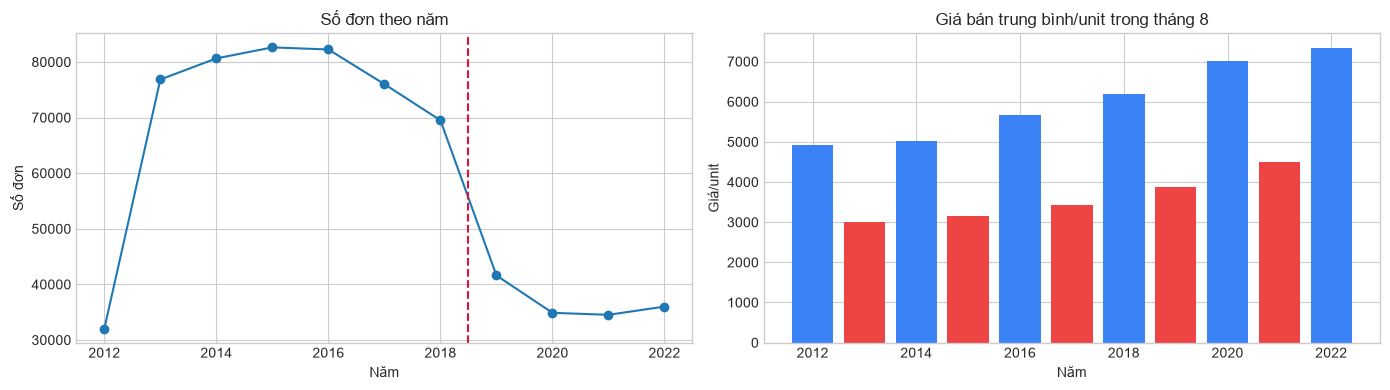

In [17]:
year_metrics = (item_fact.assign(year=item_fact.order_date.dt.year)
    .groupby('year').agg(revenue=('gross_revenue', 'sum'), orders=('order_id', 'nunique'), units=('quantity', 'sum')))
break_evidence = pd.DataFrame({
    '2018': year_metrics.loc[2018], '2019': year_metrics.loc[2019],
    'change_pct': (year_metrics.loc[2019] / year_metrics.loc[2018] - 1) * 100
})
august = item_fact[item_fact.order_date.dt.month.eq(8)].copy()
august['year'] = august.order_date.dt.year
august_year = august.groupby('year').agg(revenue=('gross_revenue', 'sum'), cogs=('line_cogs', 'sum'), units=('quantity', 'sum'))
august_year['cogs_revenue_ratio'] = august_year.cogs / august_year.revenue
august_year['price_per_unit'] = august_year.revenue / august_year.units
august_year['year_regime'] = np.where((august_year.index % 2) == 0, 'even', 'odd')
august_regime = august_year.groupby('year_regime').agg(
    years=('revenue', 'count'), revenue_mean=('revenue', 'mean'), units_mean=('units', 'mean'),
    cogs_revenue_ratio=('cogs_revenue_ratio', 'mean'), price_per_unit=('price_per_unit', 'mean'))
urban_promos = promotions[promotions.promo_name.str.contains('Urban Blowout', case=False, na=False)][
    ['promo_id', 'promo_name', 'start_date', 'end_date', 'promo_type', 'discount_value']]
print('Từ 2018 sang 2019, Revenue giảm gần tương ứng với số đơn — driver trực tiếp là order volume:')
display(break_evidence)
print('Tháng 8: units gần như không đổi nhưng giá/unit giảm mạnh ở năm lẻ:')
display(august_regime, urban_promos)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(year_metrics.index, year_metrics.orders, marker='o')
axes[0].axvline(2018.5, color='crimson', ls='--')
axes[0].set(title='Số đơn theo năm', xlabel='Năm', ylabel='Số đơn')
axes[1].bar(august_year.index, august_year.price_per_unit,
            color=np.where((august_year.index % 2) == 1, '#EF4444', '#3B82F6'))
axes[1].set(title='Giá bán trung bình/unit trong tháng 8', xlabel='Năm', ylabel='Giá/unit')
plt.tight_layout(); plt.show()

### 13.5 Chứng minh cảnh báo return là false positive do join sai

In [18]:
wrong_return_join = data['returns'].merge(
    items[['order_id', 'product_id', 'quantity']], on=['order_id', 'product_id'], how='left')
right_return_join = return_map.copy()
join_comparison = pd.DataFrame([
    {'join_key': '(order_id, product_id) — không unique', 'rows_after_join': len(wrong_return_join),
     'fan_out_rows': len(wrong_return_join)-len(data['returns']),
     'return_quantity_over_quantity': int(wrong_return_join.return_quantity.gt(wrong_return_join.quantity).sum())},
    {'join_key': '(order_id, line_number) — khóa tái dựng', 'rows_after_join': len(right_return_join),
     'fan_out_rows': len(right_return_join)-len(data['returns']),
     'return_quantity_over_quantity': int(right_return_join.return_quantity.gt(right_return_join.quantity).sum())}
])
display(join_comparison)
print('Dòng bị báo sai khi join bằng khóa không hợp lệ:')
display(wrong_return_join[wrong_return_join.return_quantity.gt(wrong_return_join.quantity)][
    ['return_id', 'order_id', 'product_id', 'return_quantity', 'quantity']])

,join_key,rows_after_join,fan_out_rows,return_quantity_over_quantity
0,"(order_id, product_id) — không unique",39943,4,1
1,"(order_id, line_number) — khóa tái dựng",39939,0,0


Dòng bị báo sai khi join bằng khóa không hợp lệ:


,return_id,order_id,product_id,return_quantity,quantity
33783,RET-043492,698128,1009,3,1


### 13.6 Bảng kết luận nguyên nhân và mức chắc chắn

In [19]:
cause_summary = pd.DataFrame([
    ('products.price', '654 SKU <100, không SKU nào từng bán; biến thể trùng nhưng giá lệch',
     'Có thể sai scale/đơn vị hoặc do bộ sinh dữ liệu', 'Giả thuyết — thiếu metadata nguồn'),
    ('customers.signup_date', '73,80% đơn trước signup; lệch trung vị 1.468 ngày',
     'Ngày signup được sinh độc lập hoặc cột bị đặt tên sai nghĩa', 'Giả thuyết mạnh'),
    ('shipments', '80.878 đơn thiếu; 80.314 thuộc created/paid/cancelled, 564 thuộc trạng thái đã fulfillment',
     'Lifecycle giải thích phần lớn; phần còn lại có thể thiếu event/không đồng bộ', 'Giải thích được một phần'),
    ('orders vs returns', '80 order status returned không có return event',
     'Khác grain/source-of-truth hoặc thiếu event', 'Chưa xác định nguyên nhân cuối'),
    ('inventory.units_sold', 'Chỉ 2,85% khớp giao dịch',
     'Measure kho dùng định nghĩa/kỳ khác hoặc được sinh độc lập', 'Giả thuyết — không có data contract nguồn'),
    ('inventory flags/DOS', '50,62% vừa stockout vừa overstock; DOS tối đa 68.100',
     'Cờ đo hai thời điểm khác nhau; DOS bùng vì units_sold nhỏ trong mẫu số', 'Cơ chế công thức đã chứng minh'),
    ('web_traffic', 'Một dòng/ngày; bounce_rate 0,0032–0,0058',
     'Nguồn đã aggregate mất grain; scale có thể là synthetic/sai semantics', 'Một phần chứng minh, một phần giả thuyết'),
    ('cuối 2018', 'Revenue -38,56%; số đơn -40,15%',
     'Driver trực tiếp là số đơn giảm; nguyên nhân business gốc không có trong dataset', 'Driver đã chứng minh, root cause chưa biết'),
    ('tháng 8 năm lẻ', 'Units gần như giữ nguyên; giá/unit giảm; COGS/Revenue tăng >1',
     'Urban Blowout đi cùng việc hạ unit_price trong khi unit COGS không đổi', 'Cơ chế dữ liệu mạnh; causal thuần chưa chứng minh'),
    ('RET-043492', 'Join sai nở 4 dòng và tạo 1 violation; join đúng có 0',
     'Dùng (order_id, product_id) không unique thay vì line_number', 'Đã chứng minh')
], columns=['where', 'evidence', 'most_plausible_cause', 'cause_status'])
display(cause_summary)

,where,evidence,most_plausible_cause,cause_status
0,products.price,"654 SKU <100, không SKU nào từng bán; biến thể...",Có thể sai scale/đơn vị hoặc do bộ sinh dữ liệu,Giả thuyết — thiếu metadata nguồn
1,customers.signup_date,"73,80% đơn trước signup; lệch trung vị 1.468 ngày",Ngày signup được sinh độc lập hoặc cột bị đặt ...,Giả thuyết mạnh
2,shipments,80.878 đơn thiếu; 80.314 thuộc created/paid/ca...,Lifecycle giải thích phần lớn; phần còn lại có...,Giải thích được một phần
3,orders vs returns,80 order status returned không có return event,Khác grain/source-of-truth hoặc thiếu event,Chưa xác định nguyên nhân cuối
4,inventory.units_sold,"Chỉ 2,85% khớp giao dịch",Measure kho dùng định nghĩa/kỳ khác hoặc được ...,Giả thuyết — không có data contract nguồn
5,inventory flags/DOS,"50,62% vừa stockout vừa overstock; DOS tối đa ...",Cờ đo hai thời điểm khác nhau; DOS bùng vì uni...,Cơ chế công thức đã chứng minh
6,web_traffic,"Một dòng/ngày; bounce_rate 0,0032–0,0058",Nguồn đã aggregate mất grain; scale có thể là ...,"Một phần chứng minh, một phần giả thuyết"
7,cuối 2018,"Revenue -38,56%; số đơn -40,15%",Driver trực tiếp là số đơn giảm; nguyên nhân b...,"Driver đã chứng minh, root cause chưa biết"
8,tháng 8 năm lẻ,Units gần như giữ nguyên; giá/unit giảm; COGS/...,Urban Blowout đi cùng việc hạ unit_price trong...,Cơ chế dữ liệu mạnh; causal thuần chưa chứng minh
9,RET-043492,Join sai nở 4 dòng và tạo 1 violation; join đú...,"Dùng (order_id, product_id) không unique thay ...",Đã chứng minh


## 14. Kết luận và bước tiếp theo

Dataset đủ để phân tích một chuỗi bán lẻ end-to-end: **demand → order → product economics → promotion → fulfillment → hậu mãi → inventory**, kèm chuỗi traffic và target theo ngày.

Ưu tiên tiếp theo:

1. Chốt một câu hỏi business cụ thể thay vì phân tích mọi thứ cùng lúc.
2. Dùng grain và khóa trong notebook này làm data contract trước mọi join.
3. Với forecasting, bắt đầu từ chuỗi ngày và calendar-derived features; không dùng trực tiếp bảng phụ ở tương lai vì chúng dừng ở 2022-12-31.
4. Với promotion, traffic hoặc region, chỉ phát biểu association nếu chưa có thiết kế causal.
5. Khi chuyển sang database, xem `docs/data-dictionary.md` và `docs/normalized_schema.md` để biết mapping 3NF.